## Effective Hyeprdegree model for Poisson hypergraph


This notebook genereated the solutions of the effective hyperdegree model used to create the phase diagram of SIS process in a hypegraph with Poisson hyperdegree distribution and uncorrelted cross-order correlation used in figure 2 of the paper 'Unveiling the impact of cross-order hyperdegree correlations in contagion processes on hypergraphs'

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx
import xgi as xgi
import random as random
import time
import sys



In [3]:
sys.path.insert(1,'../Libraries/')

from Configurational_model_HO import* #one for the configurational mdoel and another
from Overlap_func import* #for calcualte overlap of higher order netowks
from HO_effective_degree import* #contains then necesaryt functions for effective hyperdegree

In [4]:


N=1000
mu=1
k1=5
k2=3


pairs= np.loadtxt(f'../data/higherorder_networkstructures/poi_pairs_N{N}_k1{k1}_k2{k2}.txt',dtype=float).astype(int)
triples=np.loadtxt(f'../data/higherorder_networkstructures/poi_triples_N{N}_k1{k1}_k2{k2}.txt',dtype=float).astype(int)
hyper_edges=[*pairs, *triples]
    
hyper_new=[]
for edges in hyper_edges:
    new_edge=[]
    for ele in edges:
        new_edge.append(int(ele+1))
    hyper_new.append(new_edge)

lam1=1.5
lam2=4
T=20


num_inf=800
beta1=lam1*mu/k1
beta2=lam2*mu/k2
para=[beta1,beta2,mu]


results_model_reg1=odeint_effective_degree_HO_optimized(para,hyper_new,T=T,N=N,initial_infected=num_inf, steps_ode=5000)
print('')





10432
-------
10432
Starting ultra-optimized integration...
Progress: 14.4% (t=2.876, dt=0.010000)
Integration completed in 4213 steps



747.0746586000503


Text(0, 0.5, 'Population')

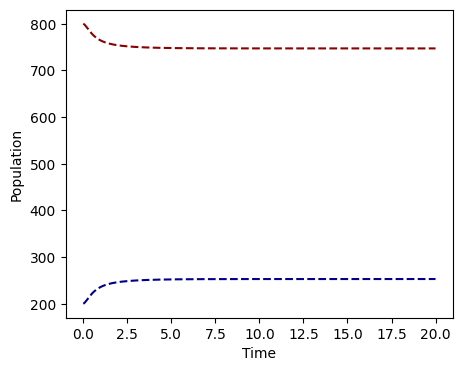

In [5]:
plt.figure(figsize=(5,4))
times,S,I=results_model_reg1

plt.plot(times,S,color='darkblue', ls='--', label='S') 
plt.plot(times,I,color='darkred', ls='--', label='I')
print(np.mean(I[-100:]))
plt.xlabel('Time')
plt.ylabel('Population')

In [6]:
def odeint_effective_degree_HO_phase_diagram_optimized(para, lambdas, hyperedges, initial_infected=None, N=1000,T=20, steps=2000):
    
    prevalence=[]
    aux, beta2, k1, k2, gamma = para
    for i in range (len(lambdas)):
        lam1=lambdas[i]
        beta1=lam1*gamma/k1
        para=[beta1,beta2,gamma]
        times, S_t, I_t= odeint_effective_degree_HO_optimized(para,hyper_new,T=T,N=N,initial_infected=initial_infected,steps_ode=steps)

        plt.show()
        prevalence.append(np.mean(I_t[-100:]))
        print('Lambda ', lam1)
        print('Prev ', prevalence[-1], times[-1])
        print('---')
        
    return prevalence

In [7]:
from datetime import datetime
start_time = datetime.now()

lambdas=np.linspace(0.001,3,100)
N=1000
mu=1
k1=5
k2=3

lam2=2.5
beta2=lam2*mu/k2


T=50


iters=100
num_inf=20
fixed_init = np.zeros((iters, num_inf), dtype=np.int64)
for h in range(iters):
    fixed_init[h] = np.random.choice(np.array(list(range(N))), num_inf, replace=False)


init_infec_num=[0]




pairs= np.loadtxt(f'../Poisson_structures/poi_pairs_uncorrIK_N{N}_k1{k1}_k2{k2}.txt',dtype=int)
triples=np.loadtxt(f'../Poisson_structures/poi_triples_uncorrIK_N{N}_k1{k1}_k2{k2}.txt', dtype=int)


hyper_edges=[*pairs, *triples]
    
hyper_new=[]
for edges in hyper_edges:
    new_edge=[]
    for ele in edges:
        new_edge.append(int(ele+1))
    hyper_new.append(new_edge)

prevalences1=[]
para=[1,beta2,k1,k2,mu]

prevalence1= odeint_effective_degree_HO_phase_diagram_optimized(para,lambdas, hyper_new,N=N,T=T,initial_infected=20)
    
#minio_helper.save_file(f'Simulation_Regular_HO_alpha0/effd_N{N}_k1{k1}_k2{k2}'+f'_prev'+'.txt',pd.DataFrame(prevalence), obj_type='csv' )
end_time = datetime.now()
print('Duration: {}'.format(end_time - start_time))


/tmp/ipykernel_1620982/1312951194.py:29: DeprecationWarning: loadtxt(): Parsing an integer via a float is deprecated.  To avoid this warning, you can:
    * make sure the original data is stored as integers.
    * use the `converters=` keyword argument.  If you only use
      NumPy 1.23 or later, `converters=float` will normally work.
    * Use `np.loadtxt(...).astype(np.int64)` parsing the file as
      floating point and then convert it.  (On all NumPy versions.)
  (Deprecated NumPy 1.23)
  pairs= np.loadtxt(f'../Poisson_structures/poi_pairs_uncorrIK_N{N}_k1{k1}_k2{k2}.txt',dtype=int)
/tmp/ipykernel_1620982/1312951194.py:30: DeprecationWarning: loadtxt(): Parsing an integer via a float is deprecated.  To avoid this warning, you can:
    * make sure the original data is stored as integers.
    * use the `converters=` keyword argument.  If you only use
      NumPy 1.23 or later, `converters=float` will normally work.
    * Use `np.loadtxt(...).astype(np.int64)` parsing the file as
    

10432
-------
10432
Starting ultra-optimized integration...
Progress: 4.3% (t=2.128, dt=0.003483)
Progress: 12.1% (t=6.059, dt=0.005015)
Progress: 28.7% (t=14.356, dt=0.010000)
Infection died out, terminating early
Integration completed in 3249 steps
Lambda  0.001
Prev  1.696519587133521e-06 16.846077501805777
---
10432
-------
10432
Starting ultra-optimized integration...
Progress: 2.7% (t=1.368, dt=0.002902)
Progress: 8.9% (t=4.434, dt=0.003483)
Progress: 22.0% (t=10.995, dt=0.010000)
Infection died out, terminating early
Integration completed in 3640 steps
Lambda  0.031292929292929296
Prev  1.6786305322671134e-06 17.39514515413819
---
10432
-------
10432
Starting ultra-optimized integration...
Progress: 5.5% (t=2.773, dt=0.004837)
Progress: 18.0% (t=8.983, dt=0.010000)
Infection died out, terminating early
Integration completed in 2887 steps
Lambda  0.06158585858585859
Prev  1.643436595342852e-06 17.853466918063614
---
10432
-------
10432
Starting ultra-optimized integration...
Prog

In [28]:
print(prevalence1)

[1.713190586658143e-06, 1.6696444428316442e-06, 1.6518720955239173e-06, 1.6017706329993575e-06, 1.570601548403413e-06, 1.5458500571922097e-06, 1.5085490928255827e-06, 1.4862868444699082e-06, 1.4624281206636502e-06, 1.43510751923727e-06, 1.4106250438583912e-06, 1.3809631470715273e-06, 1.3598886432767277e-06, 1.3333181894923983e-06, 1.3158340590594214e-06, 1.2906709434940952e-06, 1.2713112144102314e-06, 1.2495162754332871e-06, 1.2309163005770414e-06, 1.2133950845689726e-06, 1.1959223295364671e-06, 1.1780596773853205e-06, 1.1584142176011643e-06, 1.1442423584079435e-06, 1.1270865706041985e-06, 1.1102582967306639e-06, 1.0938530485516676e-06, 5.6558643668115745e-06, 9.432916092043493e-05, 0.0018490039772682551, 0.03225573733431052, 2.2926550735428894, 699.7660841789148, 703.4007448182845, 706.9114716932767, 710.3060729720488, 713.5916140113941, 716.7745120180273, 719.8606157303201, 722.8552729219014, 725.7633879296378, 728.5894709526291, 731.3376805183917, 734.0118602407466, 736.615570781371

In [9]:
np.savetxt('../data/Phase_diagram/poi_prev1.txt',prevalence1)

In [1]:
from datetime import datetime
start_time = datetime.now()

lambdas=np.linspace(0.001,3,100)
N=1000
mu=1
k1=5
k2=3

lam2=2.5
beta2=lam2*mu/k2


T=60


iters=100
num_inf=800
fixed_init = np.zeros((iters, num_inf), dtype=np.int64)
for h in range(iters):
    fixed_init[h] = np.random.choice(np.array(list(range(N))), num_inf, replace=False)
    
init_infec_num=[0]



pairs= np.loadtxt(f'../Poisson_structures/poi_pairs_uncorrIK_N{N}_k1{k1}_k2{k2}.txt',dtype=int)
triples=np.loadtxt(f'../Poisson_structures/poi_triples_uncorrIK_N{N}_k1{k1}_k2{k2}.txt', dtype=int)


hyper_edges=[*pairs, *triples]
    
hyper_new=[]
for edges in hyper_edges:
    new_edge=[]
    for ele in edges:
        new_edge.append(int(ele+1))
    hyper_new.append(new_edge)

prevalences2=[]
para=[1,beta2,k1,k2,mu]

prevalence2= odeint_effective_degree_HO_phase_diagram_optimized(para,lambdas, hyper_new,N=N,T=T,initial_infected=num_inf)
    
    
#minio_helper.save_file(f'Simulation_Regular_HO_alpha0/effd_N{N}_k1{k1}_k2{k2}'+f'_prev'+'.txt',pd.DataFrame(prevalence), obj_type='csv' )
end_time = datetime.now()
print('Duration: {}'.format(end_time - start_time))


NameError: name 'np' is not defined

In [20]:
print(prevalence2)

[1.6977656268430274e-06, 1.6684813507000409e-06, 1.638963113608961e-06, 1.6120777704099875e-06, 1.5742708129181377e-06, 1.5499243162386874e-06, 1.5152372251442804e-06, 1.485656848017604e-06, 1.462393995665516e-06, 1.4363264814218789e-06, 0.3370923026050243, 491.4130651898285, 527.1404888660777, 548.9973144906539, 565.7392117847306, 579.5934633961073, 591.5309997994067, 602.0789780641344, 611.5614726597255, 620.1945256184937, 628.130660801953, 635.482273051235, 642.3349892667012, 648.7558037759245, 654.798287999931, 660.5060659120302, 665.9152125332474, 671.0559571704417, 675.9539228367378, 680.6310474134244, 685.1062810292649, 689.3961226818464, 693.5150391694358, 697.4757963994194, 701.2897244658151, 704.9669319794812, 708.5164810321112, 711.9465312777807, 715.2644595372789, 718.4769598181566, 721.5901275285319, 724.6095308310624, 727.5402714558728, 730.387036813234, 733.1541448786344, 735.8455830374295, 738.4650418524365, 741.0159445417205, 743.501472813383, 745.9245895922223, 748.28

In [11]:
np.savetxt('../data/Phase_diagram/poi_prev2.txt',prevalence1)